# Performance testing a model on vLLM
Document the process of deploying a model with vLLM from HuggingFace and running performance testing on it with AIPerf

## Install AIPerf

```
mkdir perftest
cd perftest/
uv init
uv add aiperf
uv pip freeze | grep aiperf
source .venv/bin/activate
aiperf --version
```

## Install vLLM and deploy a model
```
uv add vllm
vllm --version
export HUGGING_FACE_HUB_TOKEN=hf_...
vllm serve TinyLlama/TinyLlama-1.1B-Chat-v1.0 --gpu-memory-utilization 0.4 --chat-template ./llama3_1_template.jinja  --api_key mynewkey
```

Where `llama3_1_template.jinja` looks like
```
{{- bos_token }}
{%- if not datetime is defined %}
    {%- set datetime = '26 Jul 2024' %}
{%- endif %}
{%- if messages[0]['role'] == 'system' %}
    {%- set loop_messages = messages[1:] %}
    {%- set system_message = messages[0]['content'] %}
{%- else %}
    {%- set loop_messages = messages %}
    {%- set system_message = false %}
{%- endif %}
{%- if system_message != false %}
    {{- '<|start_header_id|>system<|end_header_id|>\n\n' + system_message + '<|eot_id|>' }}
{%- endif %}
{%- for message in loop_messages %}
    {%- if message['role'] == 'user' %}
        {{- '<|start_header_id|>user<|end_header_id|>\n\n' + message['content'] + '<|eot_id|>' }}
    {%- elif message['role'] == 'assistant' %}
        {{- '<|start_header_id|>assistant<|end_header_id|>\n\n' + message['content'] + '<|eot_id|>' }}
    {%- endif %}
{%- endfor %}
{%- if add_generation_prompt %}
    {{- '<|start_header_id|>assistant<|end_header_id|>\n\n' }}
{%- endif %}
```

## Testing the model
```
nvidia-smi
curl http://localhost:8000/v1/models -H "Authorization: Bearer mynewkey"
```
To perform a completion
```
uv add openai
```
Edit "main.py" as follows

In [ ]:
from openai import OpenAI

# Point the OpenAI client at your local vLLM server
client = OpenAI(
        api_key="alberto",
        base_url="http://localhost:8000/v1",
        )

response = client.chat.completions.create(
        #model="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
        model="meta-llama/Llama-3.1-8B",
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": "Say hello and confirm you are running."},
            ],
         temperature=0.7,
         )

print(response.choices[0].message.content)


run it with
```uv run main.py```

## Run performance testing with AiIPerf

In [ ]:
aiperf profile  \
  --model "meta-llama/Llama-3.1-8B"  \
  --streaming \
  --endpoint-type chat \
  --tokenizer meta-llama/Llama-3.1-8B-Instruct \
  --url http://localhost:8000/v1 \
  --concurrency 5 \
  --isl 100 \
  --osl 500 \
  --request-count 50 \
  --profile-export-file in100con5

## Examine the data
Let's do some Pandas to drop the data we don't need

In [1]:
import pandas as pd
df = pd.read_csv("./artifacts/meta-llama_Llama-3.1-8B-openai-chat-concurrency5/in100con5.csv", nrows=26)
df.drop(columns=["sum", "p1", "p5", "p10", "p25", "p50", "p75", "p95"], inplace=True)
df = df[~df["Metric"].astype(str).str.contains("HTTP", na=False)]
df

,Metric,avg,min,max,p90,p99,std
0,E2E Output Token Throughput (tokens/sec/user),88.46,86.92,88.93,88.72,88.90,0.36
1,Error Input Sequence Length (tokens),100.00,100.00,100.00,100.00,100.00,0.00
16,Input Sequence Length (tokens),100.00,100.00,100.00,100.00,100.00,0.00
17,Inter Chunk Latency (ms),11.24,7.46,24.15,11.39,12.35,0.33
18,Inter Token Latency (ms),11.24,11.18,11.33,11.27,11.31,0.02
19,OSL Mismatch Diff % (%),-5.00,-79.60,0.40,0.00,0.30,17.17
20,Output Sequence Length (tokens),475.00,102.00,502.00,500.00,501.52,85.86
21,Output Token Count (tokens),475.00,102.00,502.00,500.00,501.52,85.86
22,Output Token Throughput Per User (tokens/sec/u...,88.99,88.30,89.45,89.14,89.35,0.18
23,Prefill Throughput Per User (tokens/sec/user),2624.36,1540.76,4075.98,3285.12,3728.61,590.97


## TTFT vs Tokens/s
Let's do another experiment. We can do a sweep for multiple concurrencies and see how the TTFT and the throughput grow

In [ ]:
aiperf profile --model "meta-llama/Llama-3.1-8B" --streaming --endpoint-type chat --tokenizer meta-llama/Llama-3.1-8B-Instruct --url http://localhost:8000/v1 --isl 100 --osl 128 --request-count 100 --concurrency 1
aiperf profile --model "meta-llama/Llama-3.1-8B" --streaming --endpoint-type chat --tokenizer meta-llama/Llama-3.1-8B-Instruct --url http://localhost:8000/v1 --isl 100 --osl 128 --request-count 200 --concurrency 4
aiperf profile --model "meta-llama/Llama-3.1-8B" --streaming --endpoint-type chat --tokenizer meta-llama/Llama-3.1-8B-Instruct --url http://localhost:8000/v1 --isl 100 --osl 128 --request-count 300 --concurrency 8
aiperf profile --model "meta-llama/Llama-3.1-8B" --streaming --endpoint-type chat --tokenizer meta-llama/Llama-3.1-8B-Instruct --url http://localhost:8000/v1 --isl 100 --osl 128 --request-count 400 --concurrency 16


Extracted the 2 values manually from each ".csv". Let's do the graph

Plot successfully saved as 'throughput_vs_ttft.png'


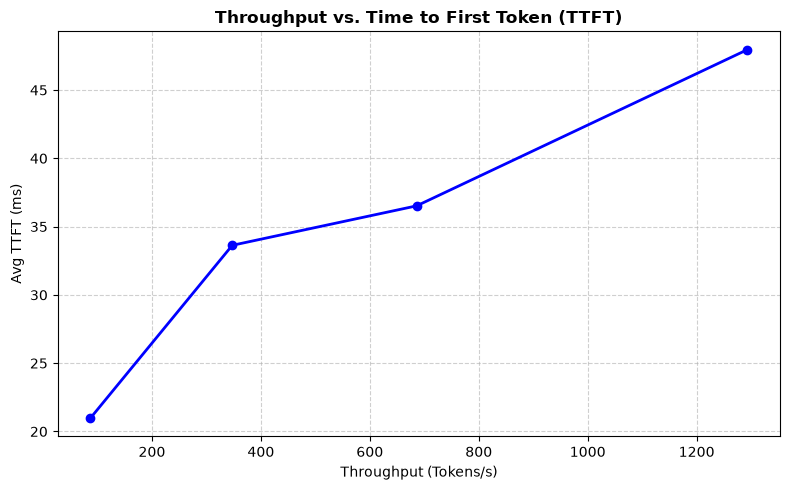

In [6]:
import matplotlib.pyplot as plt

# X-axis: Tokens/s
avg_tokens_s = [87.13, 347.46, 685.96, 1292.74]

# Y-axis: Time to First Token in ms
avg_ttft_ms = [20.98, 33.63, 36.52, 47.95]

plt.figure(figsize=(8, 5))
plt.plot(
    avg_tokens_s, 
    avg_ttft_ms, 
    marker='o', 
    color='b', 
    linewidth=2, 
    label='TTFT Curve'
)

plt.title('Throughput vs. Time to First Token (TTFT)', fontsize=12, fontweight='bold')
plt.xlabel('Throughput (Tokens/s)', fontsize=10)
plt.ylabel('Avg TTFT (ms)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

# 5. Save and Display
plt.tight_layout()
plt.savefig('throughput_vs_ttft.png', dpi=300)
print("Plot successfully saved as 'throughput_vs_ttft.png'")


At concurrency 16, the TTFT is still acceptable for most use cases and we have managed to increase throughput by 14x 